In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("loan_approval.csv")

In [3]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [4]:
df.shape

(2000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [6]:
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['city'].value_counts()

city
North Joseph        4
Port Christopher    3
North David         3
West Melissa        3
Williamsstad        3
                   ..
North Adamtown      1
Christophertown     1
West Aaron          1
Kelseyfort          1
Bakermouth          1
Name: count, Length: 1882, dtype: int64

In [15]:
df['city'].nunique()

1882

In [16]:
df = df.drop(['name', 'city'], axis=1)

In [18]:
df = df.astype(int)

<Axes: >

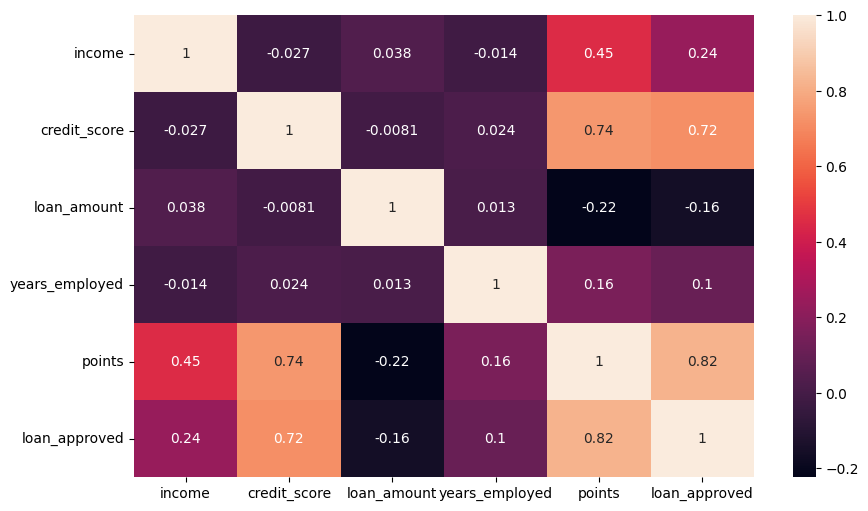

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [22]:
df.columns

Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points',
       'loan_approved'],
      dtype='object')

In [23]:
from sklearn.preprocessing import StandardScaler
cols = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']
scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])

In [24]:
df.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,0.673565,-1.152134,1.013076,0.557034,-0.358497,0
1,-1.333961,0.965919,-0.694358,0.641960,-0.090161,0
2,-1.662100,0.062632,-0.994067,-0.631939,-0.626832,0
3,1.061799,-1.432464,1.655511,0.726887,-0.358497,0
4,-0.711674,-0.485570,1.539415,-1.396279,-1.700175,0


In [25]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'income', 'credit_score', 'loan_amount', 'years_employed', 'points',
       'loan_approved'
]

# Calculate Pearson correlation
correlations = {
    feature: pearsonr(df[feature], df['loan_approved'])[0]
    for feature in selected_features
}

# Convert to DataFrame for display
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])

# Show the results
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
5,loan_approved,1.000000
4,points,0.821415
1,credit_score,0.715788
0,income,0.238066
3,years_employed,0.104408
2,loan_amount,-0.157859


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [29]:
from sklearn.linear_model import LogisticRegression

In [31]:
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
y_pred_lr = model_lr.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [36]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[217   0]
 [  0 183]]


In [37]:
vprint(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [38]:
ridge_model = LogisticRegression(
    penalty='l2',
    C=0.1,
    solver='liblinear'
)

ridge_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [39]:
y_pred_r = ridge_model.predict(X_test)

In [40]:
accuracy = accuracy_score(y_test, y_pred_r)
print("Accuracy:", accuracy)

Accuracy: 0.9575


In [41]:
cm = confusion_matrix(y_test, y_pred_r)

print(cm)

[[212   5]
 [ 12 171]]


In [42]:
print(classification_report(y_test, y_pred_r))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       217
           1       0.97      0.93      0.95       183

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [43]:
lasso_model = LogisticRegression(
    penalty='l1',
    C=0.1,
    solver='liblinear'
)

lasso_model.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [44]:
y_pred_l = ridge_model.predict(X_test)

In [45]:
accuracy = accuracy_score(y_test, y_pred_l)
accuracy

0.9575

In [46]:
cm = confusion_matrix(y_test, y_pred_l)

print(cm)

[[212   5]
 [ 12 171]]


In [47]:
print(classification_report(y_test, y_pred_l))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       217
           1       0.97      0.93      0.95       183

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [50]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [51]:
print("Accuracy:", accuracy_score(y_test, gb_pred))

print(classification_report(y_test, gb_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

